In [22]:
# =========================================================
# MACHINE LEARNING PIPELINE FOR PREDICTING P REMOVAL
# =========================================================

import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install shap
import shap

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# =========================================================
# 1. CREATE OUTPUT FOLDERS
# =========================================================
os.makedirs("Outputs_P", exist_ok=True)
os.makedirs("Publication_Figures_P", exist_ok=True)
os.makedirs("SHAP_Figures_P", exist_ok=True)

print("\n================ STEP 1: OUTPUT FOLDERS CREATED ================\n")


================ STEP 1: OUTPUT FOLDERS CREATED ================



In [24]:
# =========================================================
# 2. LOAD DATA
# =========================================================
file_path = "C:/Users/Otuo-Akyampong/OneDrive - Saint Louis University/Desktop/Data for ML modes/P_Data.xlsx"   # change path if needed
df = pd.read_excel(file_path)

print("================ STEP 2: DATA LOADED ================\n")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns in dataset:")
print(df.columns.tolist())


================ STEP 2: DATA LOADED ================

Dataset shape: (69, 8)

First 5 rows:
  Biofilter_id Group  Initial P conc (mg–P/L)  Initial N conc (mg–N/L)  \
0        Exp_1   Exp                     0.51                    10.25   
1        Exp_2   Exp                     0.51                    10.25   
2        Exp_3   Exp                     0.51                    10.25   
3        Exp_1   Exp                     0.54                    10.26   
4        Exp_2   Exp                     0.54                    10.26   

   DryingPeriod (days)  Residence Time (hrs)  Light duration (hrs)  \
0                    2              3.397243                    12   
1                    2              2.971178                    12   
2                    2              3.477444                    12   
3                    2              3.397243                    12   
4                    2              2.971178                    12   

   P Removal Eff (%)  
0          74.5098

In [25]:
# =========================================================
# 3. BASIC CLEANING
# =========================================================
df.columns = df.columns.str.strip()

if "Group" in df.columns and df["Group"].nunique() <= 1:
    df = df.drop(columns=["Group"])

print("\n================ STEP 3: BASIC CLEANING ================\n")
print("Missing values per column:")
print(df.isnull().sum())



================ STEP 3: BASIC CLEANING ================

Missing values per column:
Biofilter_id               0
Initial P conc (mg–P/L)    0
Initial N conc (mg–N/L)    0
DryingPeriod (days)        0
Residence Time (hrs)       0
Light duration (hrs)       0
P Removal Eff (%)          0
dtype: int64


In [26]:
# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================
#df["NP_ratio"] = df["Initial N conc (mg–N/L)"] / df["Initial P conc (mg–P/L)"]
#df["Loading_Intensity"] = df["Initial N conc (mg/L)"] / df["Residence Time (hrs)"]
#df["P_Loading_Intensity"] = df["Initial P conc (mg/L)"] / df["Residence Time (hrs)"]

print("\n================ STEP 4: FEATURE ENGINEERING ================\n")
print("Columns after feature engineering:")
print(df.columns.tolist())

print("\nPreview of engineered features:")
print(df[[
    "Initial P conc (mg–P/L)",
    "Initial N conc (mg–N/L)",
    "Residence Time (hrs)",
    #"NP_ratio"
    #"Loading_Intensity",
    #"P_Loading_Intensity"
]].head())

# =========================================================


================ STEP 4: FEATURE ENGINEERING ================

Columns after feature engineering:
['Biofilter_id', 'Initial P conc (mg–P/L)', 'Initial N conc (mg–N/L)', 'DryingPeriod (days)', 'Residence Time (hrs)', 'Light duration (hrs)', 'P Removal Eff (%)']

Preview of engineered features:
   Initial P conc (mg–P/L)  Initial N conc (mg–N/L)  Residence Time (hrs)
0                     0.51                    10.25              3.397243
1                     0.51                    10.25              2.971178
2                     0.51                    10.25              3.477444
3                     0.54                    10.26              3.397243
4                     0.54                    10.26              2.971178


In [27]:
# =========================================================
# 5. DEFINE INPUTS AND OUTPUT
# =========================================================

target_col = "P Removal Eff (%)"

numeric_features = [
    "Initial P conc (mg–P/L)",
    "Initial N conc (mg–N/L)",
    "Residence Time (hrs)"
]

categorical_features = [
    "DryingPeriod (days)",
    "Light duration (hrs)"
]

feature_cols = numeric_features + categorical_features

# Convert treatment variables to categorical
df["DryingPeriod (days)"] = df["DryingPeriod (days)"].astype(str)
df["Light duration (hrs)"] = df["Light duration (hrs)"].astype(str)

X = df[feature_cols].copy()
y = df[target_col].copy()

print("\n================ STEP 5a: INPUTS AND OUTPUT DEFINED ================\n")

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


================ STEP 5a: INPUTS AND OUTPUT DEFINED ================

Numerical features:
['Initial P conc (mg–P/L)', 'Initial N conc (mg–N/L)', 'Residence Time (hrs)']

Categorical features:
['DryingPeriod (days)', 'Light duration (hrs)']

X shape: (69, 5)
y shape: (69,)


In [28]:
# =========================================================
# 6. TRAIN-TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("\n================ STEP 6: TRAIN-TEST SPLIT ================\n")
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("\nX_train preview:")
print(X_train.head())

print("\ny_train preview:")
print(y_train.head())




================ STEP 6: TRAIN-TEST SPLIT ================

Train size: 55
Test size: 14

X_train preview:
    Initial P conc (mg–P/L)  Initial N conc (mg–N/L)  Residence Time (hrs)  \
68                     0.55                    10.01              2.971178   
30                     0.70                     8.92              3.477444   
57                     0.37                     8.56              3.477444   
35                     0.66                    11.07              7.903333   
56                     0.37                     8.56              2.971178   

   DryingPeriod (days) Light duration (hrs)  
68                   2                   16  
30                   7                   12  
57                   2                    8  
35                   2                   12  
56                   2                    8  

y_train preview:
68    78.181818
30    81.428571
57    79.069767
35    84.848485
56    81.081081
Name: P Removal Eff (%), dtype: float64


In [29]:
# =========================================================
# 7. PREPROCESSOR
# =========================================================

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\n================ STEP 7: PREPROCESSOR DEFINED ================\n")
print(preprocessor)



================ STEP 7: PREPROCESSOR DEFINED ================

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Initial P conc (mg–P/L)',
                                  'Initial N conc (mg–N/L)',
                                  'Residence Time (hrs)']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['DryingPeriod (days)',
                                  'Light duration (hrs)'])])


In [30]:
# =========================================================
# 8. METRIC FUNCTIONS
# =========================================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def variance_of_error(y_true, y_pred):
    errors = np.array(y_true) - np.array(y_pred)
    return np.var(errors, ddof=0)

def nse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (numerator / denominator)



def prei(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    nonzero_mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask]))

def evaluate_model(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Variance_of_Error": variance_of_error(y_true, y_pred),
        "NSE": nse(y_true, y_pred),
        "PREI": prei(y_true, y_pred)
    }

print("\n================ STEP 8: METRIC FUNCTIONS READY ================\n")



================ STEP 8: METRIC FUNCTIONS READY ================



In [31]:
# =========================================================
# 9. DEFINE MODELS
# =========================================================
gpr_kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1)

!pip install xgboost
from xgboost import XGBRegressor
models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.01))
    ]),

    "ElasticNet": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ]),

    "SVR (RBF)": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale"))
    ]),

    "Gaussian Process Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GaussianProcessRegressor(
            kernel=gpr_kernel,
            random_state=42,
            normalize_y=True
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "Extra Trees": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42
        ))
    ])
}

print("\n================ STEP 9: MODELS DEFINED ================\n")
print("Models included:")
for model_name in models.keys():
    print("-", model_name)



================ STEP 9: MODELS DEFINED ================

Models included:
- Linear Regression
- Ridge Regression
- Lasso Regression
- ElasticNet
- SVR (RBF)
- Gaussian Process Regression
- Random Forest
- Gradient Boosting
- Extra Trees
- XGBoost



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# =========================================================
# 10a. HYPERPARAMETER TUNING, TRAINING, TESTING, AND EVALUATION
# =========================================================


kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "Linear Regression": {},

    "Ridge Regression": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },

    "Lasso Regression": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10]
    },

    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },

    "SVR (RBF)": {
        "model__C": [0.1, 1, 10, 50, 100],
        "model__epsilon": [0.01, 0.05, 0.1, 0.2],
        "model__gamma": ["scale", "auto", 0.01, 0.1, 1]
    },

    "Gaussian Process Regression": {
        "model__alpha": [1e-10, 1e-6, 1e-4, 1e-3, 1e-2]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 3, 5, 7, 10],
        "model__min_samples_split": [2, 4, 6],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5]
    },

    "Extra Trees": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 3, 5, 7, 10],
        "model__min_samples_split": [2, 4, 6],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0]
    }
}

tuned_models = {}
tuning_results = []
test_results = []

print("\n================ STEP 10b: HYPERPARAMETER TUNING AND TESTING ================\n")

for name, model in models.items():

    print(f"\nTuning model: {name}")

    if param_grids[name] == {}:
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = "Default"
        best_cv_score = np.nan

    else:
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grids[name],
            n_iter=30,
            scoring="r2",
            cv=kf,
            random_state=42,
            n_jobs=-1
        )

        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        best_params = search.best_params_
        best_cv_score = search.best_score_

    tuned_models[name] = best_model

    y_pred_test = best_model.predict(X_test)

    metrics = evaluate_model(y_test, y_pred_test)
    metrics["Model"] = name
    test_results.append(metrics)

    tuning_results.append({
        "Model": name,
        "Best_CV_R2": best_cv_score,
        "Best_Params": best_params
    })

tuned_results_df = pd.DataFrame(test_results)
tuned_results_df = tuned_results_df[
    ["Model", "R2", "RMSE", "MAE", "Variance_of_Error", "NSE", "PREI"]
].sort_values(by="R2", ascending=False)

tuning_results_df = pd.DataFrame(tuning_results)

print("\n================ TUNED TEST-SET PERFORMANCE ================\n")
print(tuned_results_df.round(4))

print("\n================ BEST HYPERPARAMETERS ================\n")
print(tuning_results_df)

tuned_results_df.to_csv("Outputs_P/ML_Tuned_Test_Performance.csv", index=False)
tuning_results_df.to_csv("Outputs_P/ML_Hyperparameter_Tuning_Results.csv", index=False)

print("\nSaved:")
print("- Outputs_P/ML_Tuned_Test_Performance.csv")
print("- Outputs_P/ML_Hyperparameter_Tuning_Results.csv")


================ STEP 10b: HYPERPARAMETER TUNING AND TESTING ================


Tuning model: Linear Regression

Tuning model: Ridge Regression

Tuning model: Lasso Regression

Tuning model: ElasticNet

Tuning model: SVR (RBF)

Tuning model: Gaussian Process Regression

Tuning model: Random Forest

Tuning model: Gradient Boosting

Tuning model: Extra Trees

Tuning model: XGBoost

================ TUNED TEST-SET PERFORMANCE ================

                         Model      R2     RMSE      MAE  Variance_of_Error  \
4                    SVR (RBF)  0.6595   5.6846   4.5497            24.7678   
5  Gaussian Process Regression  0.6035   6.1344   5.0697            31.8455   
9                      XGBoost  0.1849   8.7952   7.5662            67.8917   
8                  Extra Trees  0.1625   8.9151   7.1858            56.5161   
2             Lasso Regression -0.0078   9.7799   7.6052            94.9052   
6                Random Forest -0.0164   9.8213   7.6843            76.9255   
1

In [36]:
# =========================================================
# 11 LEAVE-ONE-BIOFILTER-OUT CROSS-VALIDATION
# =========================================================

groups = df["Biofilter_id"]

logo = LeaveOneGroupOut()

logo_results = []

print("\n================ LEAVE-ONE-BIOFILTER-OUT CV ================\n")

for name, model in tuned_models.items():

    y_logo_pred = cross_val_predict(
        model,
        X,
        y,
        cv=logo,
        groups=groups
    )

    metrics = evaluate_model(y, y_logo_pred)

    metrics["Model"] = name

    logo_results.append(metrics)

logo_results_df = pd.DataFrame(logo_results)

logo_results_df = logo_results_df[
    ["Model", "R2", "RMSE", "MAE",
     "Variance_of_Error", "NSE", "PREI"]
].sort_values(by="R2", ascending=False)

print(logo_results_df.round(4))

logo_results_df.to_csv(
    "Outputs_P/ML_LOBO_Performance.csv",
    index=False
)

print("\nSaved: Outputs_P/ML_LOBO_Performance.csv")


================ LEAVE-ONE-BIOFILTER-OUT CV ================

                         Model      R2     RMSE     MAE  Variance_of_Error  \
4                    SVR (RBF)  0.7207   6.0817  4.5873            36.9846   
5  Gaussian Process Regression  0.7154   6.1391  4.5272            37.6217   
7            Gradient Boosting  0.6103   7.1838  5.1805            51.1609   
9                      XGBoost  0.3697   9.1363  6.3527            83.4657   
6                Random Forest  0.2093  10.2324  7.1549           102.9821   
0            Linear Regression  0.1310  10.7272  7.9792           115.0639   
8                  Extra Trees  0.0828  11.0210  7.7535           118.1706   
3                   ElasticNet  0.0242  11.3675  7.6717           129.2195   
1             Ridge Regression  0.0147  11.4225  7.6756           130.4727   
2             Lasso Regression -0.0029  11.5241  7.6858           132.8042   

      NSE     PREI  
4  0.7207   6.7879  
5  0.7154   6.7996  
7  0.6103   7.7


================ STEP 12: OBSERVED VS PREDICTED (TUNED MODELS) ================



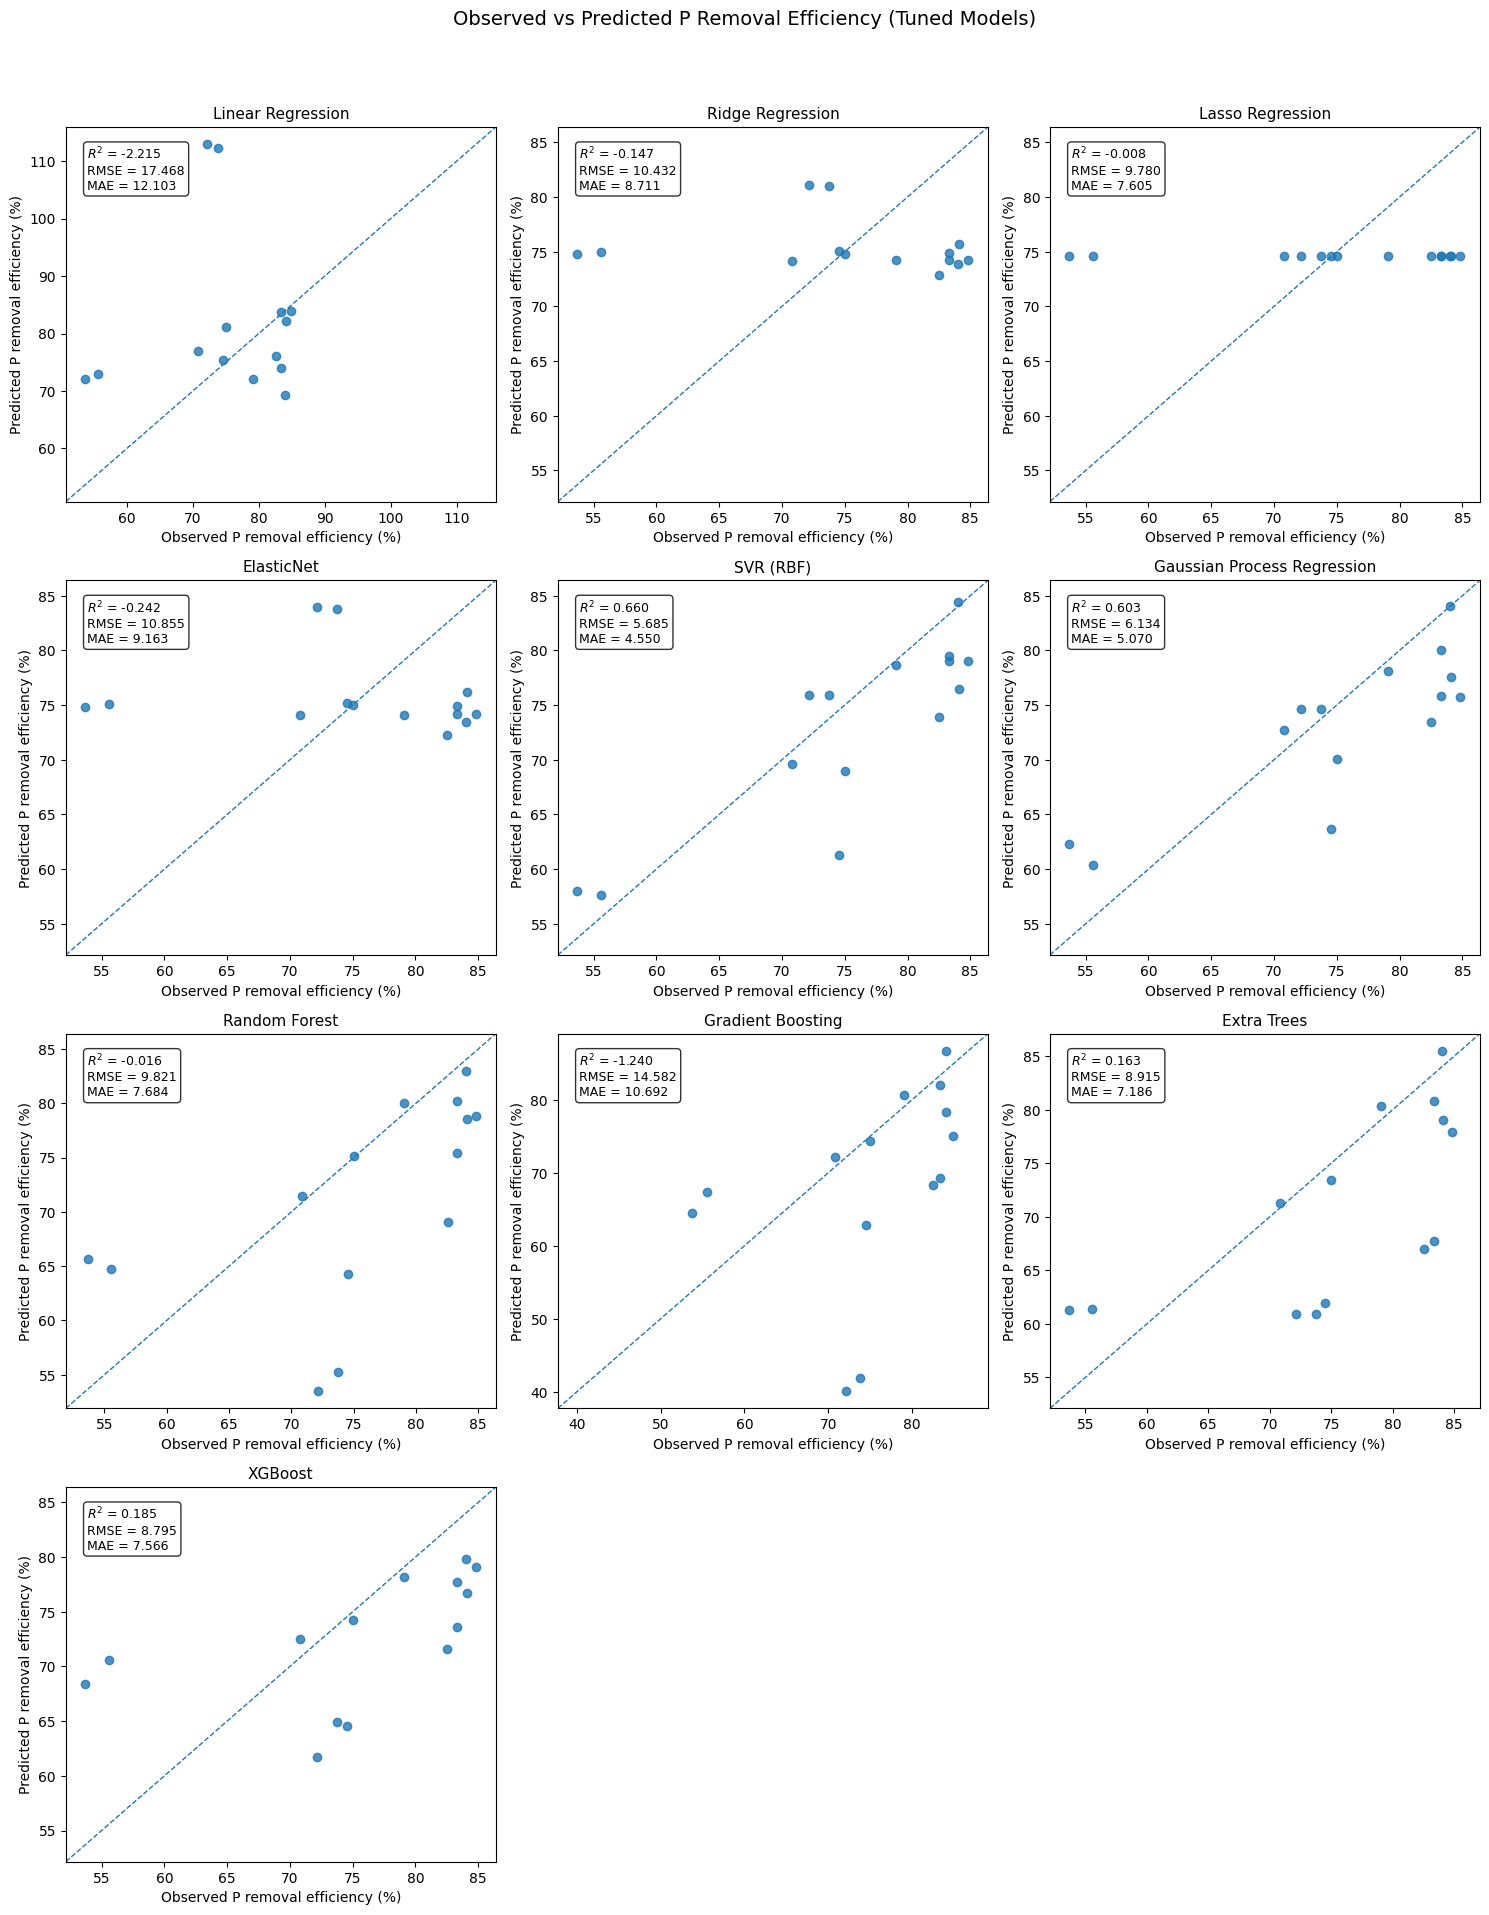


Saved:
- Publication_Figures_P/Tuned_Observed_vs_Predicted_All_Models.png
- Publication_Figures_P/Tuned_Observed_vs_Predicted_All_Models.tiff


In [37]:
# =========================================================
# 12. OBSERVED VS PREDICTED FIGURE FOR TUNED MODELS
# =========================================================

print("\n================ STEP 12: OBSERVED VS PREDICTED (TUNED MODELS) ================\n")

import math

n_models = len(tuned_models)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4.8*nrows)
)

axes = np.array(axes).reshape(-1)

for ax, (name, model) in zip(axes, tuned_models.items()):

    # Predictions from tuned model
    y_pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Axis limits
    min_val = min(np.min(y_test), np.min(y_pred))
    max_val = max(np.max(y_test), np.max(y_pred))

    pad = 0.05 * (max_val - min_val)

    x1 = min_val - pad
    x2 = max_val + pad

    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.8)

    # 1:1 line
    ax.plot(
        [x1, x2],
        [x1, x2],
        "--",
        linewidth=1
    )

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Observed P removal efficiency (%)")
    ax.set_ylabel("Predicted P removal efficiency (%)")

    ax.set_xlim(x1, x2)
    ax.set_ylim(x1, x2)

    ax.text(
        0.05,
        0.95,
        f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

# Remove empty panels
for j in range(len(tuned_models), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Observed vs Predicted P Removal Efficiency (Tuned Models)",
    fontsize=14,
    y=0.995
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "Publication_Figures_P/Tuned_Observed_vs_Predicted_All_Models.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Publication_Figures_P/Tuned_Observed_vs_Predicted_All_Models.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print("- Publication_Figures_P/Tuned_Observed_vs_Predicted_All_Models.png")
print("- Publication_Figures_P/Tuned_Observed_vs_Predicted_All_Models.tiff")


================ STEP 13: GENERATING LOBO OBSERVED VS PREDICTED FIGURE ================



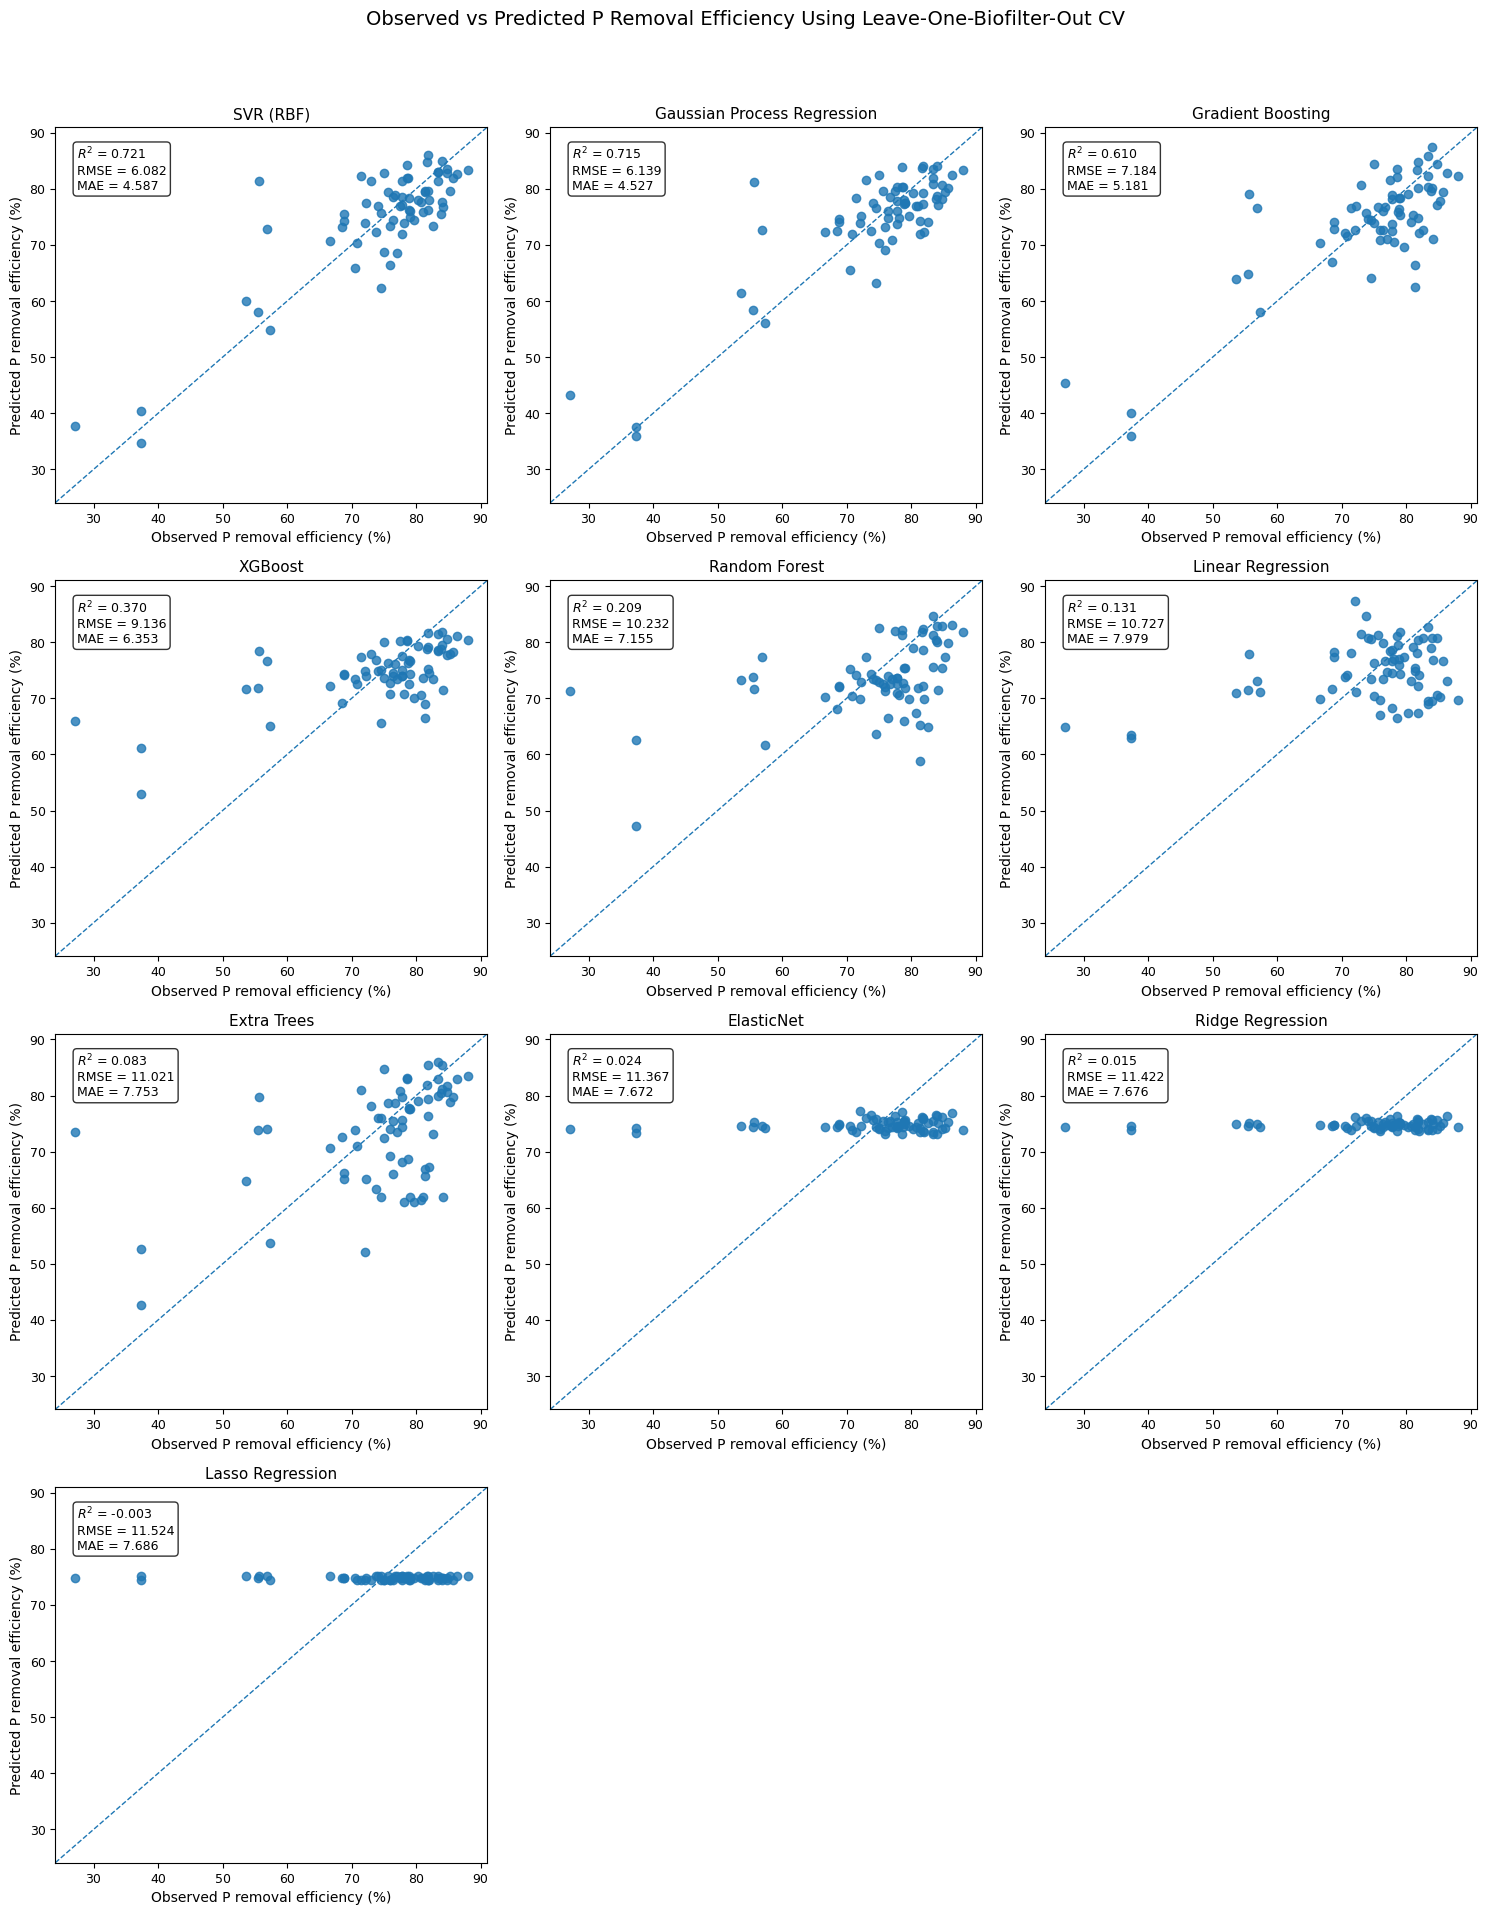

Saved:
- Publication_Figures_P/LOBO_Observed_vs_Predicted_All_Models.png
- Publication_Figures_P/LOBO_Observed_vs_Predicted_All_Models.tiff


In [38]:
# =========================================================
# 13. MULTI-PANEL OBSERVED VS PREDICTED FIGURE
# FOR ALL TUNED MODELS USING LEAVE-ONE-BIOFILTER-OUT CV
# =========================================================


print("\n================ STEP 13: GENERATING LOBO OBSERVED VS PREDICTED FIGURE ================\n")

groups = df["Biofilter_id"]
logo = LeaveOneGroupOut()

models = dict(sorted(tuned_models.items(), key=lambda x: logo_results_df.loc[logo_results_df["Model"] == x[0], "R2"].values[0], reverse=True))

n_models = len(models)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4.8*nrows)
)

axes = np.array(axes).reshape(-1)

for ax, (name, model) in zip(axes, models.items()):

    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=logo,
        groups=groups
    )

    r2 = r2_score(y, y_pred)
    RMSE = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    min_val = min(np.min(y), np.min(y_pred))
    max_val = max(np.max(y), np.max(y_pred))
    pad = 0.05 * (max_val - min_val)

    x1, x2 = min_val - pad, max_val + pad

    ax.scatter(y, y_pred, alpha=0.8)
    ax.plot([x1, x2], [x1, x2], "--", linewidth=1)

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Observed P removal efficiency (%)", fontsize=10)
    ax.set_ylabel("Predicted P removal efficiency (%)", fontsize=10)

    ax.set_xlim(x1, x2)
    ax.set_ylim(x1, x2)

    metric_text = f"$R^2$ = {r2:.3f}\nRMSE = {RMSE:.3f}\nMAE = {mae:.3f}"

    ax.text(
        0.05,
        0.95,
        metric_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8
        )
    )

    ax.tick_params(axis="both", labelsize=9)

for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Observed vs Predicted P Removal Efficiency Using Leave-One-Biofilter-Out CV",
    fontsize=14,
    y=0.995
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

fig.savefig(
    "Publication_Figures_P/LOBO_Observed_vs_Predicted_All_Models.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "Publication_Figures_P/LOBO_Observed_vs_Predicted_All_Models.tiff",
    dpi=600,
    bbox_inches="tight"
)

print("Saved:")
print("- Publication_Figures_P/LOBO_Observed_vs_Predicted_All_Models.png")
print("- Publication_Figures_P/LOBO_Observed_vs_Predicted_All_Models.tiff")


Best model based on LOBO-CV:
SVR (RBF)

Best model based on LOBO-CV:
SVR (RBF)

Feature importance for best LOBO model:
                   Feature  Importance
4     Light duration (hrs)      0.9020
3      DryingPeriod (days)      0.6922
2     Residence Time (hrs)      0.5795
0  Initial P conc (mg–P/L)      0.4627
1  Initial N conc (mg–N/L)      0.3006


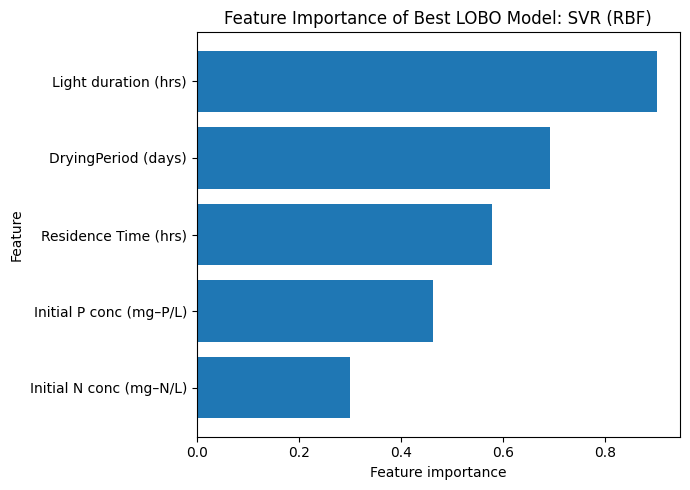


Saved:
- Outputs_P/SVR_(RBF)_LOBO_Feature_Importance.csv
- Publication_Figures_P/SVR_(RBF)_LOBO_Feature_Importance.png
- Publication_Figures_P/SVR_(RBF)_LOBO_Feature_Importance.tiff


In [39]:
# =========================================================
# 14. SELECT BEST MODEL FROM LOBO RESULTS AND PLOT FEATURE IMPORTANCE
# =========================================================

groups = df["Biofilter_id"]
logo = LeaveOneGroupOut()

# 1. Select best model from LOBO results
best_lobo_model_name = logo_results_df.iloc[0]["Model"]
best_lobo_model = tuned_models[best_lobo_model_name]

print("\nBest model based on LOBO-CV:")
print(best_lobo_model_name)
print("\nBest model based on LOBO-CV:")
print(best_lobo_model_name)

# 2. Fit best model on full dataset
best_lobo_model.fit(X, y)

# 3. Get feature importance
regressor = best_lobo_model.named_steps["model"]

if hasattr(regressor, "feature_importances_"):
    importances = regressor.feature_importances_

else:
    perm_result = permutation_importance(
        best_lobo_model,
        X,
        y,
        n_repeats=30,
        random_state=42,
        scoring="r2",
        n_jobs=-1
    )

    importances = perm_result.importances_mean

# 4. Create feature importance dataframe
fi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature importance for best LOBO model:")
print(fi_df.round(4))

fi_df.to_csv(
    f"Outputs_P/{best_lobo_model_name.replace(' ', '_')}_LOBO_Feature_Importance.csv",
    index=False
)

# 5. Plot feature importance
plt.figure(figsize=(7, 5))

plt.barh(
    fi_df["Feature"][::-1],
    fi_df["Importance"][::-1]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance of Best LOBO Model: {best_lobo_model_name}")
plt.tight_layout()

plt.savefig(
    f"Publication_Figures_P/{best_lobo_model_name.replace(' ', '_')}_LOBO_Feature_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    f"Publication_Figures_P/{best_lobo_model_name.replace(' ', '_')}_LOBO_Feature_Importance.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(f"- Outputs_P/{best_lobo_model_name.replace(' ', '_')}_LOBO_Feature_Importance.csv")
print(f"- Publication_Figures_P/{best_lobo_model_name.replace(' ', '_')}_LOBO_Feature_Importance.png")
print(f"- Publication_Figures_P/{best_lobo_model_name.replace(' ', '_')}_LOBO_Feature_Importance.tiff")


================ SHAP ANALYSIS FOR BEST LOBO MODEL ================

Best model: SVR (RBF)

================ SHAP ANALYSIS ================

Transformed X shape: (69, 9)
Number of feature names: 9


  0%|          | 0/69 [00:00<?, ?it/s]

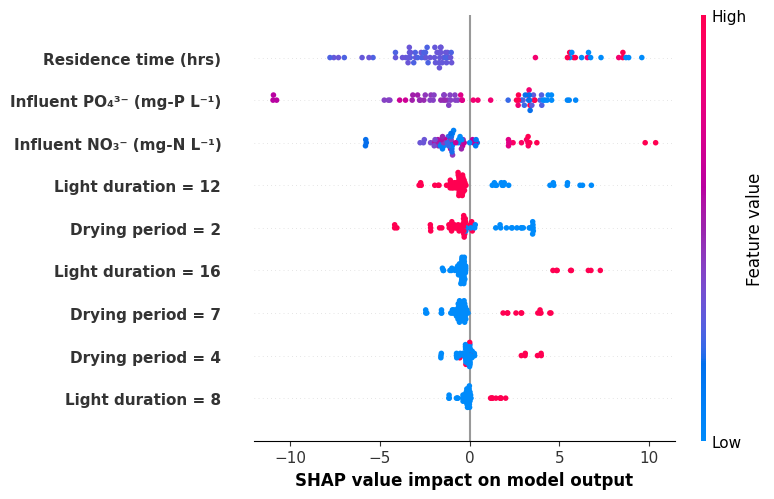


Mean absolute SHAP importance:
                     Feature  MeanAbsSHAP
2       Residence time (hrs)     3.942523
0  Influent PO₄³⁻ (mg-P L⁻¹)     3.138998
1   Influent NO₃⁻ (mg-N L⁻¹)     1.887429
6        Light duration = 12     1.471703
3          Drying period = 2     1.346968
7        Light duration = 16     1.122008
5          Drying period = 7     1.110191
4          Drying period = 4     0.530173
8         Light duration = 8     0.382468


In [40]:
# =========================================================
# 15. SHAP ANALYSIS FOR BEST LOBO MODEL
# =========================================================

print("\n================ SHAP ANALYSIS FOR BEST LOBO MODEL ================\n")
print("Best model:", best_lobo_model_name)

# Fit best model on full dataset
best_lobo_model.fit(X, y)

# =========================================================
# SHAP ANALYSIS FOR ONE-HOT ENCODED MODEL
# DryingPeriod and Light duration treated as categorical
# =========================================================


print("\n================ SHAP ANALYSIS ================\n")

# ---------------------------------------------------------
# 1. Select the fitted best model pipeline
# ---------------------------------------------------------
# Change this name if your best model variable has another name
best_pipeline = best_lobo_model  

# Extract fitted preprocessor and model
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_model = best_pipeline.named_steps["model"]

# ---------------------------------------------------------
# 2. Transform X using fitted preprocessor
# ---------------------------------------------------------
X_transformed = fitted_preprocessor.transform(X)

# Convert sparse matrix to dense if needed
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# ---------------------------------------------------------
# 3. Get correct feature names after OneHotEncoder
# ---------------------------------------------------------
feature_names = fitted_preprocessor.get_feature_names_out()

# Clean feature names for publication
clean_feature_names = (
    pd.Series(feature_names)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("DryingPeriod \\(days\\)_", "Drying period = ", regex=True)
    .str.replace("Light duration \\(hrs\\)_", "Light duration = ", regex=True)
    .str.replace("Initial P conc \\(mg–P/L\\)", "Influent PO₄³⁻ (mg-P L⁻¹)", regex=True)
    .str.replace("Initial N conc \\(mg–N/L\\)", "Influent NO₃⁻ (mg-N L⁻¹)", regex=True)
    .str.replace("Residence Time \\(hrs\\)", "Residence time (hrs)", regex=True)
)

print("Transformed X shape:", X_transformed.shape)
print("Number of feature names:", len(clean_feature_names))

# ---------------------------------------------------------
# 4. Create SHAP explainer
# ---------------------------------------------------------
model_name = fitted_model.__class__.__name__

if model_name in [
    "RandomForestRegressor",
    "ExtraTreesRegressor",
    "GradientBoostingRegressor",
    "XGBRegressor"
]:
    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_transformed)

else:
    # General fallback for SVR, GPR, linear models, etc.
    background = shap.sample(X_transformed, min(50, X_transformed.shape[0]), random_state=42)
    explainer = shap.KernelExplainer(fitted_model.predict, background)
    shap_values = explainer.shap_values(X_transformed)

# ---------------------------------------------------------
# 5. SHAP summary plot
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=clean_feature_names,
    show=False
)

plt.xlabel("SHAP value impact on model output", fontsize=12, fontweight="bold")
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, fontweight="bold")

plt.tight_layout()

os.makedirs("SHAP_Figures_P", exist_ok=True)

plt.savefig(
    "SHAP_Figures_P/P_SHAP_summary_onehot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "SHAP_Figures_P/P_SHAP_summary_onehot.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 6. Mean absolute SHAP importance table
# ---------------------------------------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("\nMean absolute SHAP importance:")
print(shap_importance_df)

shap_importance_df.to_csv(
    "SHAP_Figures_P/P_SHAP_importance_onehot.csv",
    index=False
)

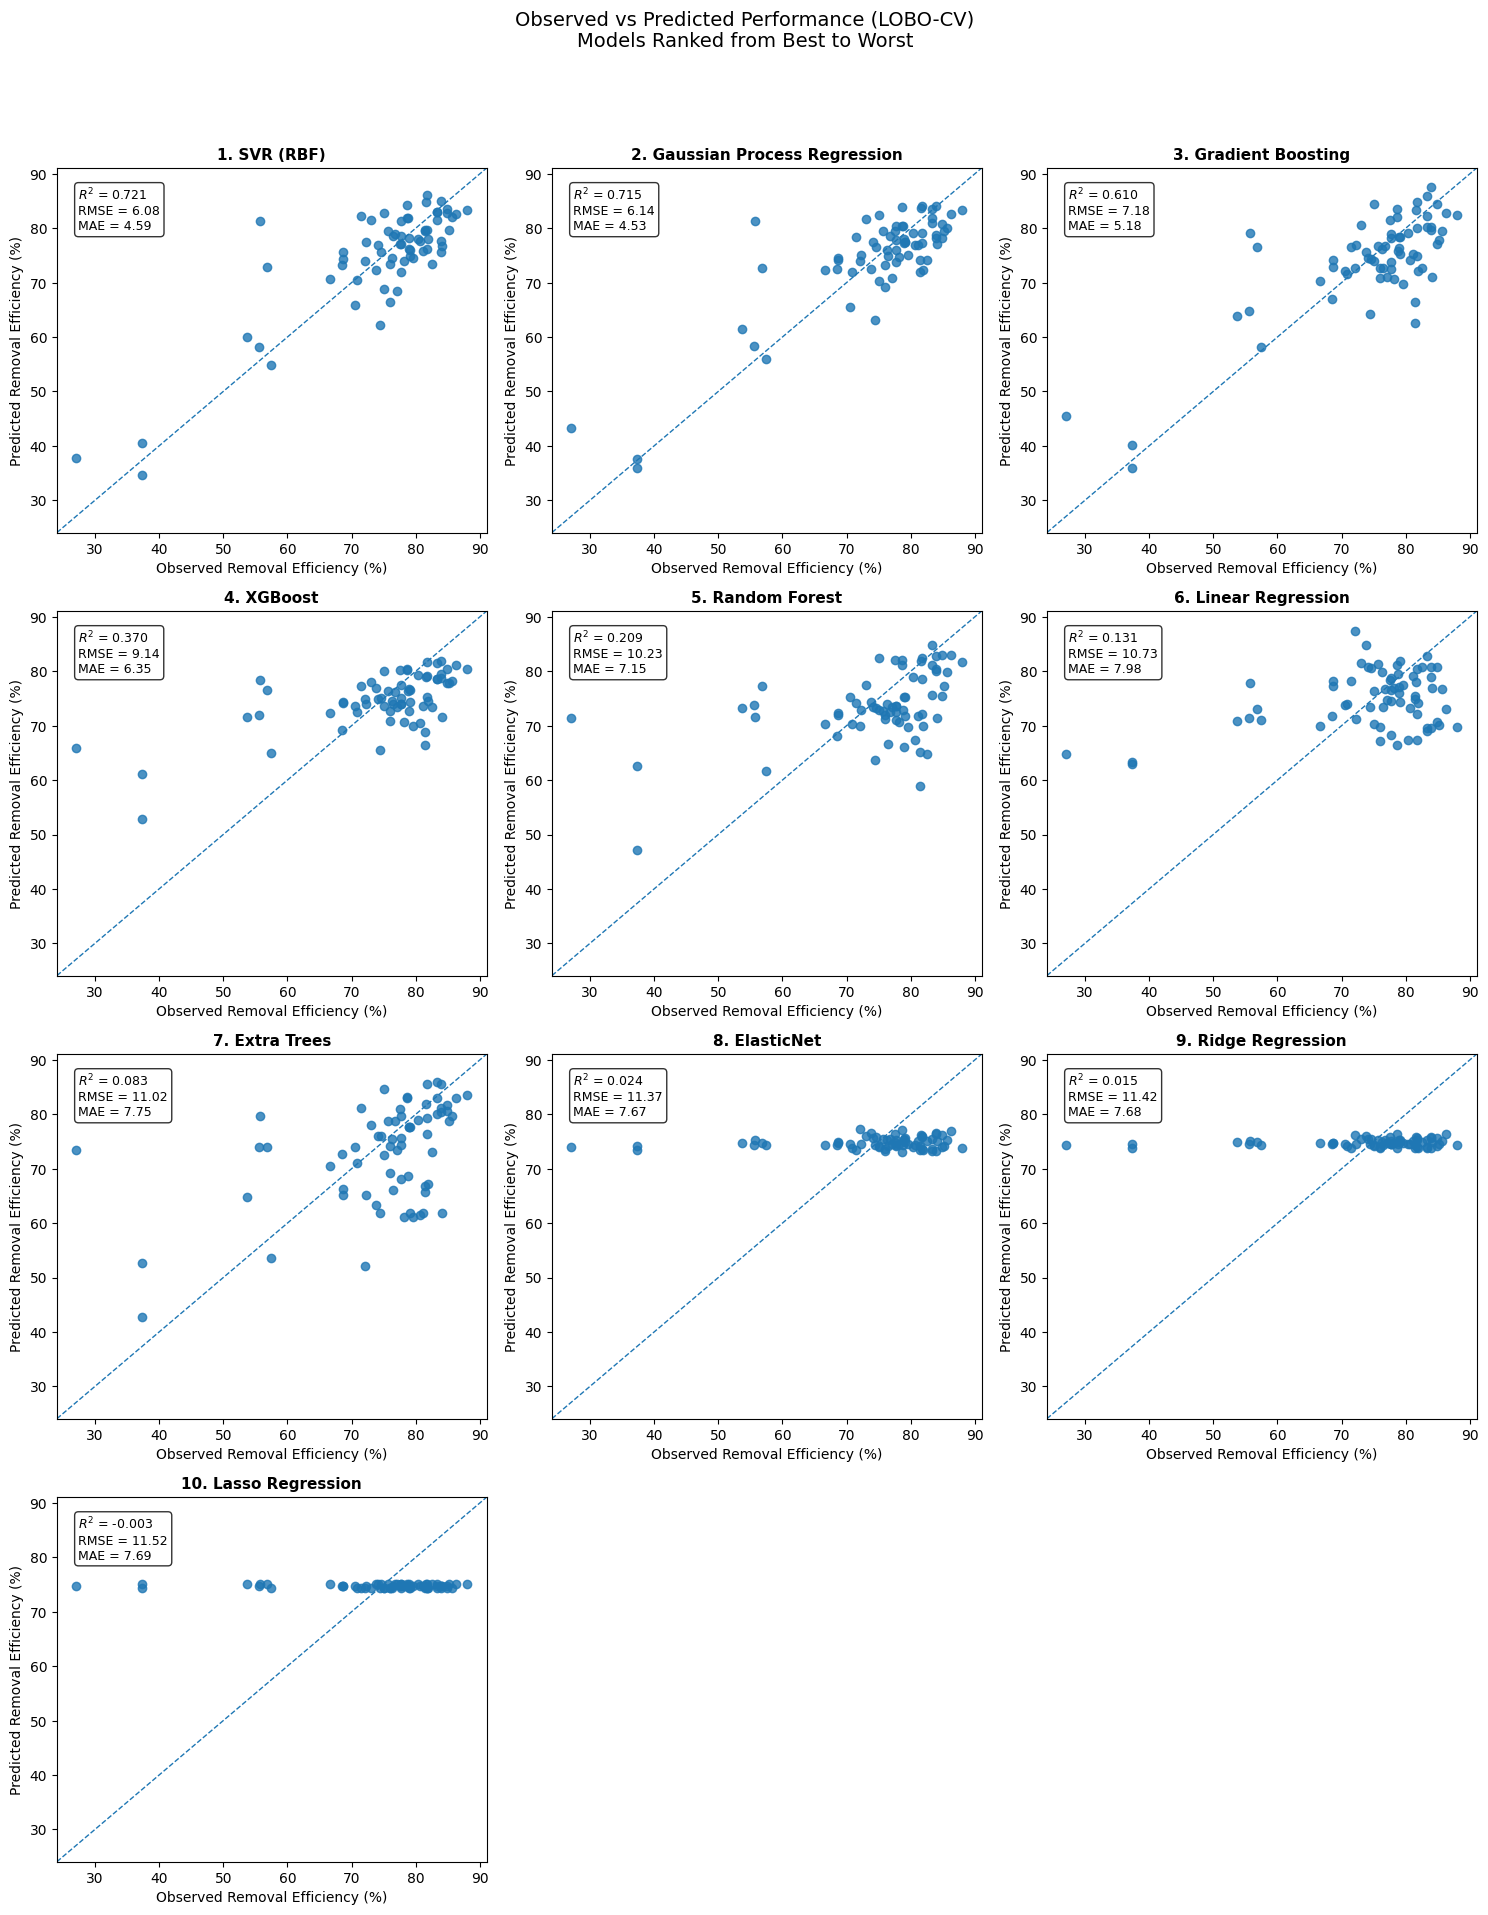


Saved:
- Publication_Figures_P/LOBO_Ranked_Observed_vs_Predicted.png
- Publication_Figures_P/LOBO_Ranked_Observed_vs_Predicted.tiff


In [41]:
# =========================================================
# 16. OBSERVED VS PREDICTED
# ORDERED BY LOBO PERFORMANCE (BEST → WORST)
# =========================================================

groups = df["Biofilter_id"]
logo = LeaveOneGroupOut()

# Models ordered by LOBO R²
ordered_models = logo_results_df["Model"].tolist()

n_models = len(ordered_models)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4.8*nrows)
)

axes = np.array(axes).reshape(-1)

for i, model_name in enumerate(ordered_models):

    ax = axes[i]

    model = tuned_models[model_name]

    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=logo,
        groups=groups
    )

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    min_val = min(np.min(y), np.min(y_pred))
    max_val = max(np.max(y), np.max(y_pred))

    pad = 0.05 * (max_val - min_val)

    x1 = min_val - pad
    x2 = max_val + pad

    ax.scatter(y, y_pred, alpha=0.8)

    ax.plot(
        [x1, x2],
        [x1, x2],
        "--",
        linewidth=1
    )

    ax.set_title(
        f"{i+1}. {model_name}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Observed Removal Efficiency (%)",
        fontsize=10
    )

    ax.set_ylabel(
        "Predicted Removal Efficiency (%)",
        fontsize=10
    )

    ax.set_xlim(x1, x2)
    ax.set_ylim(x1, x2)

    ax.text(
        0.05,
        0.95,
        f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

# Remove unused panels
for j in range(n_models, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Observed vs Predicted Performance (LOBO-CV)\nModels Ranked from Best to Worst",
    fontsize=14,
    y=0.995
)

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "Publication_Figures_P/LOBO_Ranked_Observed_vs_Predicted.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Publication_Figures_P/LOBO_Ranked_Observed_vs_Predicted.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print("- Publication_Figures_P/LOBO_Ranked_Observed_vs_Predicted.png")
print("- Publication_Figures_P/LOBO_Ranked_Observed_vs_Predicted.tiff")


================ GENERATING LOBO FIGURE FOR NONLINEAR MODELS ONLY ================



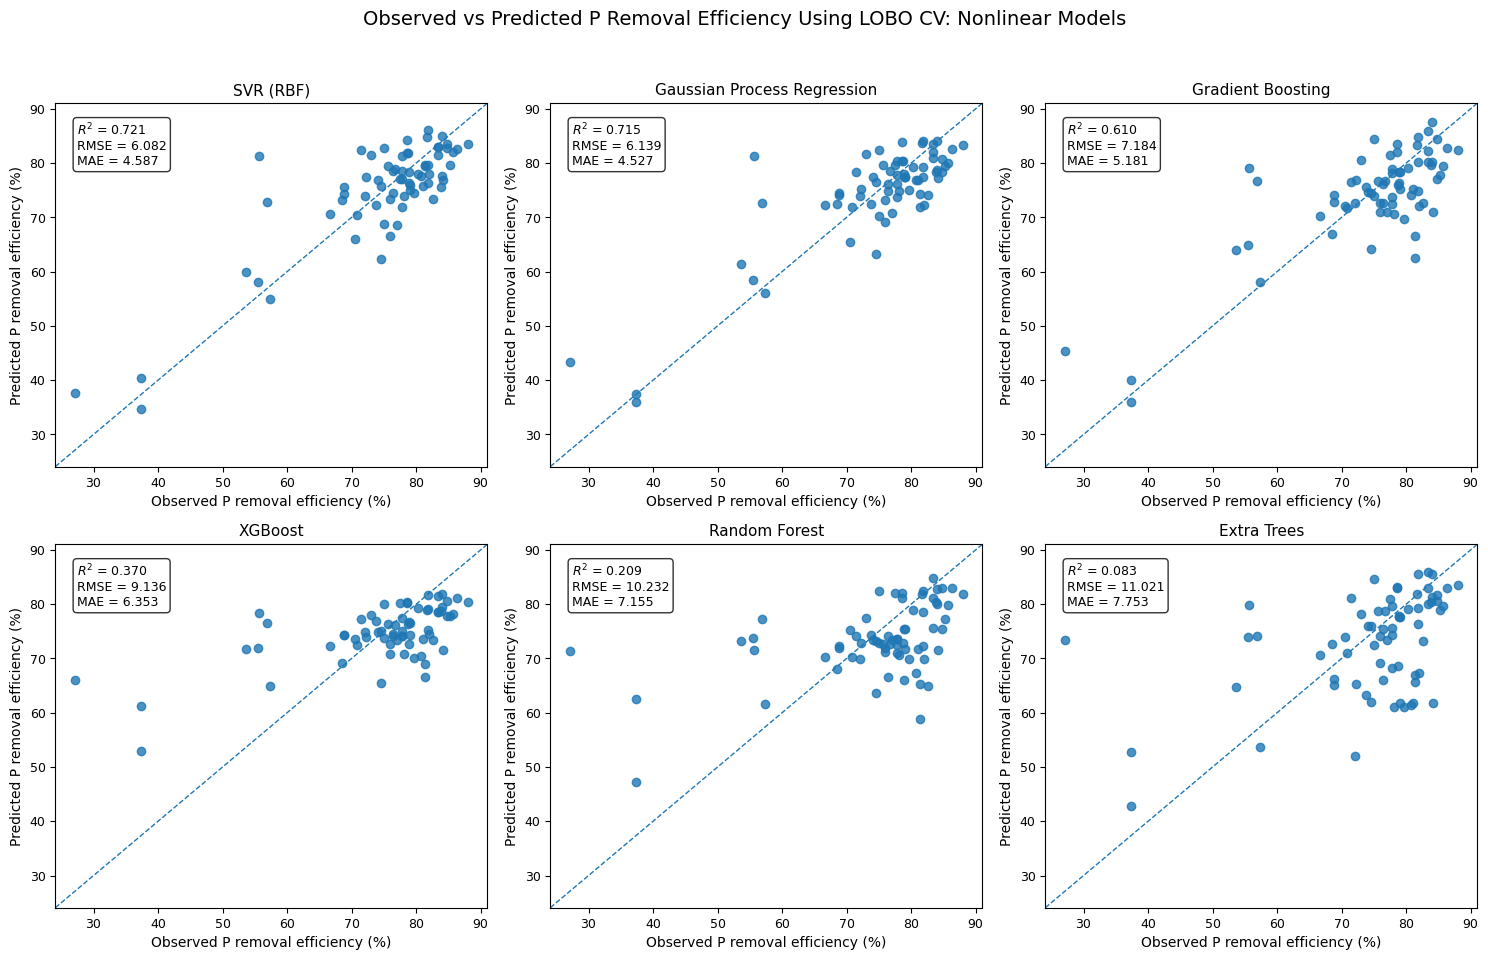

Saved:
- Publication_Figures_P/LOBO_Observed_vs_Predicted_Nonlinear_Models.png
- Publication_Figures_P/LOBO_Observed_vs_Predicted_Nonlinear_Models.tiff


In [42]:
# =========================================================
# 17. LOBO OBSERVED VS PREDICTED FIGURE
# NONLINEAR MODELS ONLY
# =========================================================

print("\n================ GENERATING LOBO FIGURE FOR NONLINEAR MODELS ONLY ================\n")

groups = df["Biofilter_id"]
logo = LeaveOneGroupOut()

nonlinear_model_names = [
    "Gaussian Process Regression",
    "Gradient Boosting",
    "XGBoost",
    "SVR (RBF)",
    "Random Forest",
    "Extra Trees"
]

nonlinear_models = {
    name: models[name]
    for name in nonlinear_model_names
    if name in models
}

lobo_results = []

for name, model in nonlinear_models.items():

    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=logo,
        groups=groups
    )

    r2 = r2_score(y, y_pred)
    RMSE = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    lobo_results.append({
        "Model": name,
        "Model_Object": model,
        "R2": r2,
        "RMSE": RMSE,
        "MAE": mae,
        "Predictions": y_pred
    })

lobo_results = sorted(
    lobo_results,
    key=lambda x: x["R2"],
    reverse=True
)

n_models = len(lobo_results)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4.8*nrows)
)

axes = np.array(axes).reshape(-1)

for ax, result in zip(axes, lobo_results):

    name = result["Model"]
    y_pred = result["Predictions"]
    r2 = result["R2"]
    RMSE = result["RMSE"]
    mae = result["MAE"]

    min_val = min(np.min(y), np.min(y_pred))
    max_val = max(np.max(y), np.max(y_pred))
    pad = 0.05 * (max_val - min_val)

    x1, x2 = min_val - pad, max_val + pad

    ax.scatter(y, y_pred, alpha=0.8)
    ax.plot([x1, x2], [x1, x2], "--", linewidth=1)

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Observed P removal efficiency (%)", fontsize=10)
    ax.set_ylabel("Predicted P removal efficiency (%)", fontsize=10)

    ax.set_xlim(x1, x2)
    ax.set_ylim(x1, x2)

    metric_text = f"$R^2$ = {r2:.3f}\nRMSE = {RMSE:.3f}\nMAE = {mae:.3f}"

    ax.text(
        0.05,
        0.95,
        metric_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8
        )
    )

    ax.tick_params(axis="both", labelsize=9)

for j in range(len(lobo_results), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Observed vs Predicted P Removal Efficiency Using LOBO CV: Nonlinear Models",
    fontsize=14,
    y=0.995
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

fig.savefig(
    "Publication_Figures_P/LOBO_Observed_vs_Predicted_Nonlinear_Models.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "Publication_Figures_P/LOBO_Observed_vs_Predicted_Nonlinear_Models.tiff",
    dpi=600,
    bbox_inches="tight"
)

print("Saved:")
print("- Publication_Figures_P/LOBO_Observed_vs_Predicted_Nonlinear_Models.png")
print("- Publication_Figures_P/LOBO_Observed_vs_Predicted_Nonlinear_Models.tiff")